In [1]:
import os
import random
import trimesh

BASE_PATH = '/ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/03001627'
NUM_SAMPLES = 16

model_dirs = [d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))]
selected_ids = random.sample(model_dirs, NUM_SAMPLES)

mesh_list = []
for model_id in selected_ids:
    path = os.path.join(BASE_PATH, model_id, 'models', 'model_normalized.obj')
    try:
        mesh = trimesh.load(path, force='mesh')
        # # Optional: Simplify to ~2000 faces so Matplotlib doesn't crawl
        # mesh = mesh.simplify_quadratic_decimation(2000)
        mesh_list.append((model_id, mesh))
    except Exception as e:
        print(f"Skipping {model_id}: {e}")

print(f"Successfully loaded {len(mesh_list)} meshes.")

Successfully loaded 16 meshes.


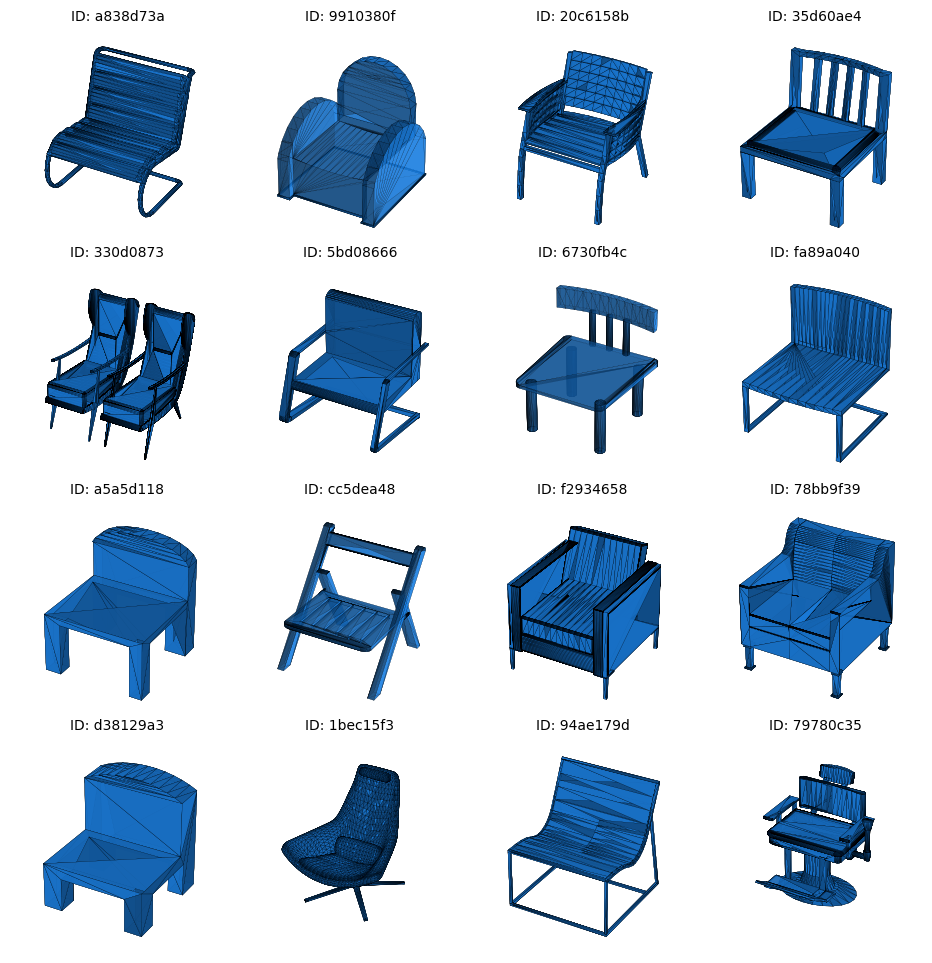

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 12))
fig.patch.set_facecolor('white')

for i, (model_id, mesh) in enumerate(mesh_list):
    ax = fig.add_subplot(4, 4, i + 1, projection='3d')
    v = mesh.vertices
    f = mesh.faces
    ax.plot_trisurf(v[:, 0], v[:, 2], v[:, 1], triangles=f, 
                    color='dodgerblue', edgecolor='k', linewidth=0.1, alpha=0.7)
    ax.set_title(f"ID: {model_id[:8]}", fontsize=10)
    ax.set_axis_off()
    ax.set_box_aspect([1,1,1]) 

plt.subplots_adjust(wspace=0, hspace=0.1)
plt.show()

# Autoencoder

In [5]:
from model import PointCloudAE